### Downstream analysis FUNPROFILER, module: func_classification_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p funprofiler
```

In [115]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)

options(readr.show_col_types = FALSE)

In [116]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [117]:
file <- "./tables/funprofiler/raw_counts_intersect_bp.tsv"

read_funcprofiler <- function(file) {
  otu <- as.data.frame(read_delim(paste0(file),
    delim = "\t"
    ))
    #otu$ID <- paste0("", seq_len(nrow(otu)))
  rownames(otu) <- otu$ko_id
  otu_num <- otu[, -1]
  return(data.frame(otu_num))
}

In [118]:
otu <- read_funcprofiler(file)

In [119]:
head(otu)

,CR18_ER180415_F,CR18_ER180415_S,CR18_LE180416_F,CR18_LE180416_S,CR18_XF180416_F,CR18_XF180416_S,CR18_LW180405_F,CR18_LW180405_S
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
K00001,11000,10000,13000,8000,15000,6000,0,4000
K00002,0,0,0,0,0,1000,0,0
K00003,36000,27000,41000,28000,46000,19000,4000,11000
K00004,13000,4000,5000,3000,6000,5000,1000,5000
K00005,1000,1000,2000,0,4000,0,0,0
K00007,1000,1000,1000,1000,1000,1000,0,1000


In [120]:
taxa <- as.data.frame(read_delim("./tables/ko_carbon_metab.csv",
                    delim = ',',  # Note: read.delim uses 'sep', read_delim uses 'delim'
                    locale = locale(decimal_mark = ",")
                    ))

rownames(taxa) <- taxa$ko

In [121]:
env <- as.data.frame(read_delim("./cr18_env_geomosaicPlot.csv",
                  delim = ",",
                  skip = 1,
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample

# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa_df)),
  sample_data(env)
)

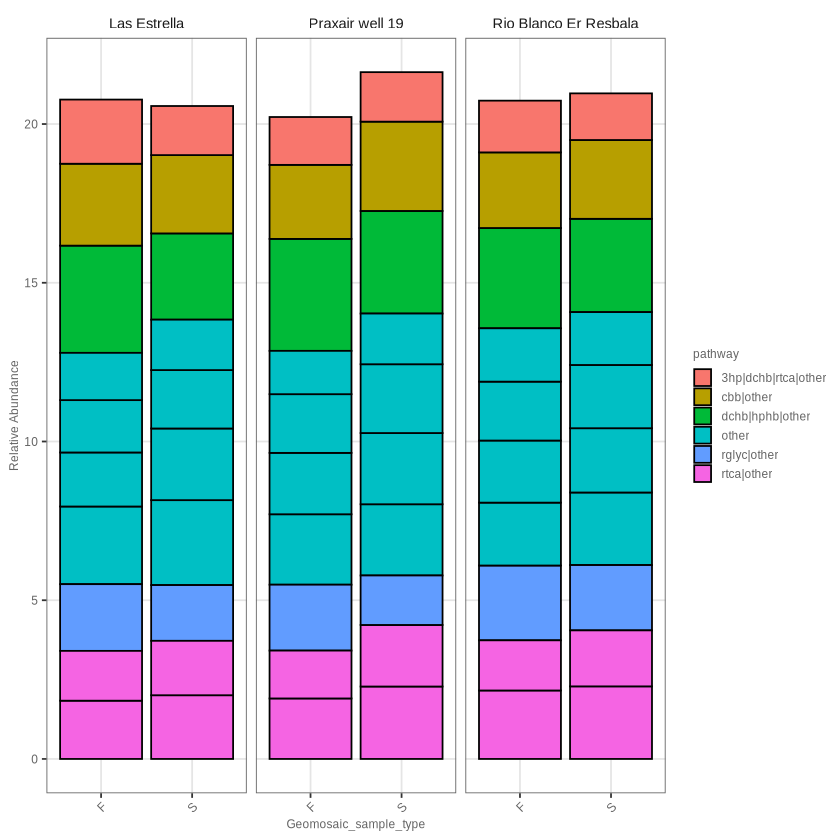

In [132]:
func_ndata_ra <- transform_sample_counts(phy, function(x) x/sum(x) * 100 )
N <- 10

top10.genes <- sort(taxa_sums(func_ndata_ra), decreasing = TRUE)[1:N]
func.top10.ra <- prune_taxa(names(top10.genes), func_ndata_ra)

plot_bar(func.top10.ra, x = "Geomosaic_sample_type", fill="pathway") +
  facet_grid(~site_name, scales = "free", space = "free") +
  labs(y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    strip.text.y = element_blank(),  # Rimuove il testo delle righe del facet_grid
    strip.background = element_blank(),  # Rimuove il box di background delle righe del facet_grid
    legend.position = "right",
    panel.grid.major = element_line(color = "grey90")
  )

In [122]:
get_rpoB_total <- function(df) {
  df[] <- lapply(df, as.numeric)
  colSums(df[c("K03043","K13797"), , drop=FALSE], na.rm=TRUE) +
    colMeans(df[c("K03044","K03045"), , drop=FALSE], na.rm=TRUE) +
    as.numeric(df["K13798", , drop=TRUE])
}

In [123]:
# Set ko_id as rownames and keep only numeric columns
otu_mat <- otu
rownames(otu_mat) <- otu_mat$ko_id
otu_mat <- otu_mat[, -1]                          # drop ko_id column
otu_mat[] <- lapply(otu_mat, as.numeric)           # ensure numeric

# Compute per-sample rpoB total (single-copy marker gene equivalents)
rpob_total <- get_rpoB_total(otu_mat)
cat("rpoB totals per sample:\n")
print(rpob_total)

# Result: copies per genome equivalent (relative abundance proxy)
otu_rpob_norm <- sweep(otu_mat, 2, rpob_total, FUN = "/")

# Restore ko_id as first column for downstream use
otu_rpob_norm <- data.frame(
  ko_id = rownames(otu_rpob_norm),
  otu_rpob_norm,
  check.names = FALSE
)
rownames(otu_rpob_norm) <- NULL

cat("rpoB-normalized table (first 6 rows):\n")
print(head(otu_rpob_norm))

rpoB totals per sample:
CR18_ER180415_S CR18_LE180416_F CR18_LE180416_S CR18_XF180416_F CR18_XF180416_S 
             NA              NA              NA              NA              NA 
CR18_LW180405_F CR18_LW180405_S 
             NA              NA 
rpoB-normalized table (first 6 rows):
  ko_id CR18_ER180415_S CR18_LE180416_F CR18_LE180416_S CR18_XF180416_F
1     1              NA              NA              NA              NA
2     2              NA              NA              NA              NA
3     3              NA              NA              NA              NA
4     4              NA              NA              NA              NA
5     5              NA              NA              NA              NA
6     6              NA              NA              NA              NA
  CR18_XF180416_S CR18_LW180405_F CR18_LW180405_S
1              NA              NA              NA
2              NA              NA              NA
3              NA              NA              NA
4     